# Leaf Pest / Disease Severity Analysis — SAM 3 + LAB color anomaly (hybrid)

This notebook replaces the SAM2 pipeline (`pathosystem_severity.ipynb`). It is **not** a
straight SAM2→SAM3 swap — testing on real field images showed SAM3 alone is the wrong tool for
one half of the original pipeline. The two stages are handled differently on purpose:

| Stage | What it uses | Why |
|---|---|---|
| **Leaf selection** | SAM3, `"leaf"` text prompt, multi-instance | Genuine architectural fix over SAM2's center-point click — see Step 1. |
| **Damage detection** | SAM3 concept prompts **+ the original LAB color heuristic, unioned** | SAM3's detector predicts a fixed budget of *discrete instances* — it does well on larger, separable damage (a blight patch, a single insect) but degrades on dense, small, touching damage (mite/aphid carpets), which is a known weak spot for this whole model family, not a SAM3-specific bug. The LAB heuristic never had that problem: it's a per-pixel anomaly test, so it doesn't care whether damage is one blob or two hundred touching ones. Each method is kept where it's actually stronger instead of picking one as "the upgrade." |

**What changed vs. the SAM2 pipeline, stage by stage:**
- Leaf: no more center-point assumption. SAM3 returns every leaf instance in frame; the target
  is chosen explicitly (Step 1), and other leaves are reported, not silently merged.
- Damage: still LAB color anomaly at full resolution for area coverage (Step 2, Layer B) — but
  now it runs *inside* a leaf mask that's actually reliable, instead of a leaf mask that could
  silently include a background leaf. SAM3 concept prompts (Step 2, Layer A) run alongside it
  for typed, counted, confidence-scored detections on the damage that's large/separable enough
  for an instance detector to see.
- The manual `MODE = "lesion" | "insect"` switch is gone — both the `a*` and `L*` color
  hypotheses run automatically every time, same as SAM3's multiple concept prompts.

**Still true regardless of pipeline version** (carried over from the earlier review):
- SAM3's text vocabulary is general-purpose, not agricultural-pathology-specific — use concrete,
  concrete-looking terms (`"aphid"`, `"powdery mildew"`) not category words (`"pest"`,
  `"disease"`, `"damage"`), which have no single consistent visual pattern to ground on.
- `DAMAGE_PROMPTS`, `confidence_threshold`, and the color heuristic's `COLOR_K`/`COLOR_MIN_BLOB`
  are all tuning surfaces that need calibration against a held-out eval set — nothing here is
  self-calibrating.

Run cells top to bottom. Requires a GPU runtime (Colab: **Runtime → Change runtime type → GPU**).


## Setup

In [ ]:
!pip install -q "numpy<2.0" opencv-python-headless scipy matplotlib
!pip install -q 'git+https://github.com/facebookresearch/sam3.git'

# sam3 pins numpy < 2.0. If this cell just downgraded numpy in a fresh Colab
# session, restart the runtime (Runtime > Restart session) before continuing,
# then skip re-running this install cell.
print("If NumPy was just installed/downgraded, restart the runtime now, then continue from the next cell.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 38.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 22.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.11.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.14.0.

**SAM 3 checkpoints are gated.** Before the model-build cell below will work, request access at
the [SAM 3 Hugging Face repo](https://huggingface.co/facebook/sam3) and authenticate in this
environment. Uncomment and run the cell below once per environment if you haven't already.

In [ ]:
# from huggingface_hub import login
# login()  # paste an access token with access to facebook/sam3 when prompted

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

import sam3
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import normalize_bbox

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    print("WARNING: no CUDA device found. SAM3 defaults to device='cuda' internally and is "
          "not validated on CPU-only setups in the official examples — expect this to be slow "
          "or to fail. Get a GPU runtime if possible.")
else:
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

print("Device:", DEVICE)

/usr/local/lib/python3.13/dist-packages/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Device: cuda


## Build model

In [ ]:
sam3_root = os.path.dirname(sam3.__file__)
bpe_path = os.path.join(sam3_root, "assets", "bpe_simple_vocab_16e6.txt.gz")

model = build_sam3_image_model(bpe_path=bpe_path, device=DEVICE)
processor = Sam3Processor(model, device=DEVICE, confidence_threshold=0.5)
print("Ready.")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

Ready.


## Upload an image

In [ ]:
from google.colab import files
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]
print("Loaded:", IMG_PATH)

Saving leaf_spot.jpg to leaf_spot.jpg
Loaded: leaf_spot.jpg


## Helper functions

`masks_to_numpy` pulls the raw detections (masks / boxes / scores) out of a `Sam3Processor`
state dict — the official example notebook only ever calls `plot_results()`, which is
visualization-only and doesn't expose the arrays you need to compute severity.

`pick_target_leaf` replaces the SAM2 pipeline's center-point click. It still uses "is this
roughly centered" as a signal — but now it's a tie-breaker applied *after* seeing every leaf
SAM3 found, not the entire basis for segmentation. If nothing overlaps the center (e.g. an
off-center crop), it falls back to the largest detected leaf and tells you it did so, instead
of silently segmenting the wrong object.

`color_anomaly_mask` is `propose_candidates()` from the original SAM2 notebook, ported over
almost unchanged — full-resolution LAB color statistics, no model involved. The only real
change: it used to hand boxes off to SAM2 for boundary refinement; here the thresholded,
cleaned-up blobs are used directly as the damage mask, since a segmentation model isn't needed
just to compute area coverage, and re-boxing hundreds of small touching blobs would just
reintroduce the crowded-scene problem this function exists to avoid.

In [ ]:
def masks_to_numpy(state):
    '''Extract (masks[N,H,W] bool, boxes[N,4] xyxy px, scores[N]) from a Sam3Processor state.

    Cast to float32 before .numpy(): under the bfloat16 autocast entered in the
    Setup cell (for GPU speed, matching Meta's own example), these tensors come
    back as bf16. NumPy has no native bf16 dtype, so a direct .cpu().numpy() call
    raises `TypeError: Got unsupported ScalarType BFloat16`.
    '''
    if "masks" not in state or state["masks"].shape[0] == 0:
        h, w = state["original_height"], state["original_width"]
        return np.zeros((0, h, w), bool), np.zeros((0, 4)), np.zeros((0,))
    masks = state["masks"].squeeze(1).detach().to(torch.float32).cpu().numpy().astype(bool)   # [N, H, W]
    boxes = state["boxes"].detach().to(torch.float32).cpu().numpy()                          # [N, 4] xyxy, pixels
    scores = state["scores"].detach().to(torch.float32).cpu().numpy()                        # [N]
    return masks, boxes, scores


def pick_target_leaf(masks, boxes, scores, img_w, img_h):
    '''Choose one leaf instance out of N candidates SAM3 found for the leaf prompt.

    Rule: among instances whose box contains the image center, take the largest by
    area. If none contain the center, fall back to the single largest detected leaf
    and flag that this happened, so you can catch off-center crops in review rather
    than silently mis-scoring them.
    '''
    if len(masks) == 0:
        return None, "no_leaf_found"

    cx, cy = img_w / 2.0, img_h / 2.0
    areas = masks.reshape(len(masks), -1).sum(axis=1)
    contains_center = (
        (boxes[:, 0] <= cx) & (cx <= boxes[:, 2]) &
        (boxes[:, 1] <= cy) & (cy <= boxes[:, 3])
    )

    if contains_center.any():
        idx_pool = np.where(contains_center)[0]
        idx = int(idx_pool[np.argmax(areas[idx_pool])])
        reason = "centered"
    else:
        idx = int(np.argmax(areas))
        reason = "largest_fallback_not_centered"

    return idx, reason


def color_anomaly_mask(rgb, leaf_mask, channel="a", k=1.5, min_blob=15):
    '''LAB color-space anomaly detector, ported from the original SAM2 pipeline's
    propose_candidates(). Runs on raw pixels at full resolution, independent of any
    segmentation model — this is what keeps working on dense, small, touching damage
    (mite/aphid carpets) where SAM3's DETR-style instance detector structurally
    struggles, since it has to individuate a fixed budget of separate objects rather
    than just flag anomalous pixels.

    channel="a" -> redder-than-leaf-median (fungal/bacterial lesions, rust, blight)
    channel="L" -> darker-than-leaf-median (dark pests, insect clusters, shadowed damage)
    '''
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    chan_idx = {"L": 0, "a": 1, "b": 2}[channel]
    chan = lab[:, :, chan_idx].astype(float)

    v = chan[leaf_mask]
    med = np.median(v)
    mad = np.median(np.abs(v - med)) * 1.4826 + 1e-6
    cand = (chan < med - k * mad) if channel == "L" else (chan > med + k * mad)
    cand = cand & leaf_mask
    cand = ndimage.binary_opening(cand, np.ones((3, 3)))

    lbl, n = ndimage.label(cand)
    if n == 0:
        return np.zeros_like(leaf_mask, dtype=bool)
    sizes = ndimage.sum(cand, lbl, range(1, n + 1))
    keep_ids = np.nonzero(sizes >= min_blob)[0] + 1
    return np.isin(lbl, keep_ids)

## Step 1 — Leaf instance segmentation (text-prompted, multi-instance)

`LEAF_PROMPT` is queried once; SAM3 returns *every* matching instance in the frame, not just
whatever the center pixel happens to touch. This is the direct fix for background/overlapping
leaves confusing the mask.

In [ ]:
LEAF_PROMPT = "leaf"  # try "grape leaf" if your crop is known and the plain prompt over-triggers

image = Image.open(IMG_PATH).convert("RGB")
img_w, img_h = image.size
rgb = np.array(image)

state = processor.set_image(image)
processor.reset_all_prompts(state)
state = processor.set_text_prompt(prompt=LEAF_PROMPT, state=state)

leaf_masks, leaf_boxes, leaf_scores = masks_to_numpy(state)
print(f"'{LEAF_PROMPT}' -> {len(leaf_masks)} instance(s) found")
for i, s in enumerate(leaf_scores):
    print(f"  leaf[{i}]  score={s:.2f}  area={int(leaf_masks[i].sum()):,} px")

target_idx, reason = pick_target_leaf(leaf_masks, leaf_boxes, leaf_scores, img_w, img_h)
if target_idx is None:
    raise RuntimeError(
        f"No '{LEAF_PROMPT}' instance found — try a more specific prompt (e.g. 'grape leaf'), "
        f"or lower processor.confidence_threshold and re-run this cell."
    )

leaf_mask = ndimage.binary_fill_holes(leaf_masks[target_idx])
n_other_leaves = len(leaf_masks) - 1

print(f"\nSelected leaf #{target_idx} ({reason}) — {100 * leaf_mask.mean():.1f}% of frame")
if n_other_leaves > 0:
    print(f"{n_other_leaves} other leaf instance(s) detected and excluded as background — "
          f"this is exactly the case that used to silently corrupt the SAM2 center-point mask.")

# Plausibility guard: heavy occlusion (e.g. a leaf almost entirely covered by an
# infestation) can leave nothing resembling a real leaf blade in frame. SAM3 still has
# to pick *something* in that case, usually a tiny leftover fragment — which makes
# severity (% of a near-zero leaf area) meaningless rather than merely inaccurate.
MIN_LEAF_FRACTION = 0.15  # tune to your typical framing
if leaf_mask.mean() < MIN_LEAF_FRACTION:
    print(f"\nWARNING: selected leaf covers only {100 * leaf_mask.mean():.1f}% of the frame — "
          f"likely no real leaf blade in view (heavy occlusion or wrong framing). "
          f"Severity computed below is not meaningful for this image.")

'leaf' -> 5 instance(s) found
  leaf[0]  score=0.63  area=7,395 px
  leaf[1]  score=0.76  area=13,604 px
  leaf[2]  score=0.53  area=1,590 px
  leaf[3]  score=0.74  area=5,919 px
  leaf[4]  score=0.84  area=79,121 px

Selected leaf #4 (centered) — 39.6% of frame
4 other leaf instance(s) detected and excluded as background — this is exactly the case that used to silently corrupt the SAM2 center-point mask.


## Step 2 — Damage segmentation (hybrid: SAM3 concepts ∪ LAB color anomaly)

Two independent layers, unioned:

- **Layer A — SAM3 concept prompts.** Good for damage that's large and/or visually separable:
  a blight patch, an individual insect, a mildew patch. Each concept is queried independently
  with a real confidence score, so a leaf with both fungal spots *and* insects is no longer an
  either/or choice.
- **Layer B — LAB color anomaly** (`color_anomaly_mask`, defined above). Good for damage that's
  small, dense, and touching — a mite/aphid carpet, fine stippling — exactly where an instance
  detector's fixed object budget breaks down. Both the `a*` (redder) and `L*` (darker)
  hypotheses run automatically now, replacing the old manual `MODE` switch.

**Tuning surfaces:** `DAMAGE_PROMPTS` (use concrete, visually-consistent terms — `"aphid"`, not
`"pest"`; `"leaf spot"`, not `"discoloration"`), `confidence_threshold` on the processor, and
`COLOR_K`/`COLOR_MIN_BLOB` for the color layer, same role `k`/`min_blob` played before.

In [ ]:
DAMAGE_PROMPTS = [
    "leaf lesion",
    "leaf spot",
    "powdery mildew",
    "aphid",
    "mealybug",
    "scale insect",
]

# --- Layer A: SAM3 concept prompts ---
sam3_mask = np.zeros((img_h, img_w), bool)
prompt_report = []

for prompt in DAMAGE_PROMPTS:
    processor.reset_all_prompts(state)
    state = processor.set_text_prompt(prompt=prompt, state=state)
    masks, boxes, scores = masks_to_numpy(state)

    on_leaf = np.zeros((img_h, img_w), bool)
    for m in masks:
        on_leaf |= (m & leaf_mask)
    sam3_mask |= on_leaf

    prompt_report.append({
        "prompt": prompt,
        "instances": len(masks),
        "avg_score": float(scores.mean()) if len(scores) else 0.0,
        "px_on_leaf": int(on_leaf.sum()),
    })

sam3_mask = ndimage.binary_opening(sam3_mask, np.ones((3, 3)))

# --- Layer B: LAB color anomaly (full resolution, model-independent) ---
COLOR_K = 1.5
COLOR_MIN_BLOB = 15

color_mask_lesion = color_anomaly_mask(rgb, leaf_mask, channel="a", k=COLOR_K, min_blob=COLOR_MIN_BLOB)
color_mask_insect = color_anomaly_mask(rgb, leaf_mask, channel="L", k=COLOR_K, min_blob=COLOR_MIN_BLOB)
color_mask = color_mask_lesion | color_mask_insect

# --- Union ---
damage_mask = sam3_mask | color_mask

print(f"{'Prompt':<24}{'Instances':<12}{'Avg score':<12}{'Px on leaf':<10}")
for r in prompt_report:
    print(f"{r['prompt']:<24}{r['instances']:<12}{r['avg_score']:<12.2f}{r['px_on_leaf']:<10,}")
print(f"{'SAM3 layer total':<24}{'':<12}{'':<12}{int(sam3_mask.sum()):<10,}")

print(f"\n{'Color anomaly (LAB)':<24}{'Px on leaf':<10}")
print(f"{'  a* redder (lesion-like)':<24}{int(color_mask_lesion.sum()):<10,}")
print(f"{'  L* darker (insect-like)':<24}{int(color_mask_insect.sum()):<10,}")
print(f"{'  combined':<24}{int(color_mask.sum()):<10,}")

overlap_px = int((sam3_mask & color_mask).sum())
union_px = int(damage_mask.sum())
print(f"\nOverlap between the two layers: {overlap_px:,} px "
      f"({100 * overlap_px / max(1, union_px):.1f}% of the final union)")
print(f"Final damage mask (union): {union_px:,} px")
print("\nIf one layer is contributing almost everything for your image mix, that's useful to "
      "know — e.g. dense small-pest shots will be color-layer-dominated, larger separable "
      "lesions will be SAM3-layer-dominated. See the overlap panel in Step 4.")

Prompt                  Instances   Avg score   Px on leaf
leaf lesion             0           0.00        0         
leaf spot               0           0.00        0         
powdery mildew          0           0.00        0         
aphid                   0           0.00        0         
mealybug                0           0.00        0         
scale insect            0           0.00        0         
SAM3 layer total                                0         

Color anomaly (LAB)     Px on leaf
  a* redder (lesion-like)16,651    
  L* darker (insect-like)8,244     
  combined              19,849    

Overlap between the two layers: 0 px (0.0% of the final union)
Final damage mask (union): 19,849 px

If one layer is contributing almost everything for your image mix, that's useful to know — e.g. dense small-pest shots will be color-layer-dominated, larger separable lesions will be SAM3-layer-dominated. See the overlap panel in Step 4.


### Optional — refine one concept with positive/negative exemplars

If a text prompt above over- or under-triggers (e.g. `"leaf spot"` also firing on water
droplets or vein shadows), give SAM3 a concrete example instead of relying on wording alone:
one box on a confirmed lesion (positive), optionally one box on a lookalike you want excluded
(negative).

This is manual and per-image — its real value is bootstrapping labeled data for a later
fine-tune (see the earlier fine-tuning discussion), not something you'd run at inference time
in production. Skip this cell if the prompts above already look reasonable.

In [ ]:
# Inspect the image first, e.g.:
# plt.figure(figsize=(8, 8)); plt.imshow(rgb); plt.grid(True); plt.show()

# Fill in as (x, y, w, h) pixel coordinates, (x, y) = top-left corner. Leave as None to skip.
POSITIVE_EXEMPLAR_XYWH = None  # e.g. [420, 610, 60, 45]  -- a confirmed lesion
NEGATIVE_EXEMPLAR_XYWH = None  # e.g. [180, 300, 50, 50]  -- a lookalike to exclude

if POSITIVE_EXEMPLAR_XYWH is not None:
    processor.reset_all_prompts(state)

    exemplar_boxes = [POSITIVE_EXEMPLAR_XYWH]
    exemplar_labels = [True]
    if NEGATIVE_EXEMPLAR_XYWH is not None:
        exemplar_boxes.append(NEGATIVE_EXEMPLAR_XYWH)
        exemplar_labels.append(False)

    for box_xywh, label in zip(exemplar_boxes, exemplar_labels):
        box_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_xywh, dtype=torch.float32).view(-1, 4))
        norm_box = normalize_bbox(box_cxcywh, img_w, img_h).flatten().tolist()
        state = processor.add_geometric_prompt(state=state, box=norm_box, label=label)

    masks, boxes, scores = masks_to_numpy(state)
    on_leaf = np.zeros((img_h, img_w), bool)
    for m in masks:
        on_leaf |= (m & leaf_mask)

    print(f"Exemplar refinement -> {len(masks)} instance(s), {int(on_leaf.sum()):,} px on leaf")
    sam3_mask |= on_leaf
    sam3_mask = ndimage.binary_opening(sam3_mask, np.ones((3, 3)))
    damage_mask = sam3_mask | color_mask  # re-union with the color layer from Step 2
else:
    print("Skipped — set POSITIVE_EXEMPLAR_XYWH above to try exemplar refinement on this image.")

Skipped — set POSITIVE_EXEMPLAR_XYWH above to try exemplar refinement on this image.


## Step 3 — Severity scoring

Unchanged from the SAM2 pipeline — same grade buckets, so severity numbers stay comparable across both notebooks while you validate SAM3 against your existing results.

In [ ]:
leaf_px = int(leaf_mask.sum())
damage_px = int(damage_mask.sum())
severity = 100.0 * damage_px / leaf_px if leaf_px else 0.0

def grade(pct):
    if pct < 1: return "0 - Healthy"
    if pct < 5: return "1 - Trace"
    if pct < 15: return "2 - Mild"
    if pct < 35: return "3 - Moderate"
    return "4 - Severe"

print(f"Leaf area      : {leaf_px:,} px")
print(f"Affected area  : {damage_px:,} px")
print(f"SEVERITY       : {severity:.2f}%")
print(f"Grade          : {grade(severity)}")

Leaf area      : 79,121 px
Affected area  : 19,849 px
SEVERITY       : 25.09%
Grade          : 3 - Moderate


## Step 4 — Visualization

Panel ① now shows *every* detected leaf instance (target in green, others in orange) instead of a single blob, so a background-leaf failure is visible in the plot rather than hidden inside the severity number.

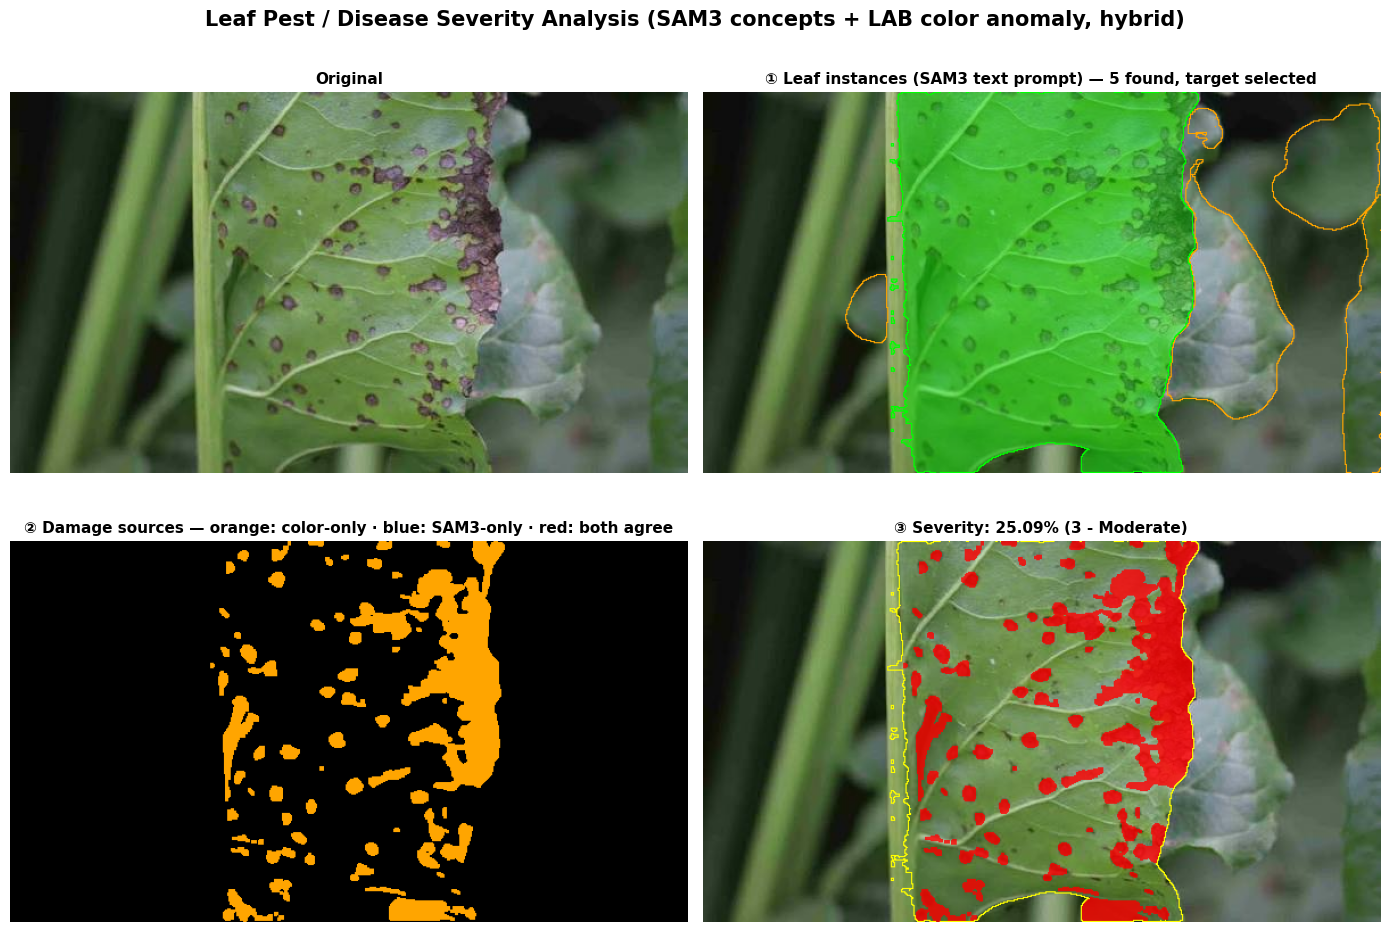


Per-prompt contribution (SAM3 layer):
  leaf lesion              instances=0    avg_score=0.00  px_on_leaf=0
  leaf spot                instances=0    avg_score=0.00  px_on_leaf=0
  powdery mildew           instances=0    avg_score=0.00  px_on_leaf=0
  aphid                    instances=0    avg_score=0.00  px_on_leaf=0
  mealybug                 instances=0    avg_score=0.00  px_on_leaf=0
  scale insect             instances=0    avg_score=0.00  px_on_leaf=0


In [ ]:
def show_results(rgb, leaf_masks, target_idx, leaf_mask, sam3_mask, color_mask, damage_mask,
                  severity, prompt_report):
    leaf_view = rgb.copy()
    for i, m in enumerate(leaf_masks):
        m_u8 = m.astype(np.uint8)
        edge = cv2.dilate(m_u8, np.ones((3, 3))) - m_u8
        color = (0, 255, 0) if i == target_idx else (255, 165, 0)
        leaf_view[edge.astype(bool)] = color
    leaf_view[leaf_mask] = (0.6 * leaf_view[leaf_mask] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)

    # which layer flagged each damage pixel — orange: color-only, blue: SAM3-only, red: both
    overlap_view = np.zeros((*leaf_mask.shape, 3), dtype=np.uint8)
    both = sam3_mask & color_mask
    color_only = color_mask & ~sam3_mask
    sam3_only = sam3_mask & ~color_mask
    overlap_view[color_only] = [255, 165, 0]
    overlap_view[sam3_only] = [0, 140, 255]
    overlap_view[both] = [255, 0, 0]

    final = rgb.copy()
    final[damage_mask] = (0.2 * final[damage_mask] + 0.8 * np.array([255, 0, 0])).astype(np.uint8)
    leaf_u8 = leaf_mask.astype(np.uint8)
    edges = cv2.dilate(leaf_u8, np.ones((3, 3))) - leaf_u8
    final[edges.astype(bool)] = [255, 255, 0]

    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    panels = [
        (rgb, "Original"),
        (leaf_view, f"\u2460 Leaf instances (SAM3 text prompt) \u2014 {len(leaf_masks)} found, target selected"),
        (overlap_view, "\u2461 Damage sources \u2014 orange: color-only \u00b7 blue: SAM3-only \u00b7 red: both agree"),
        (final, f"\u2462 Severity: {severity:.2f}% ({grade(severity)})"),
    ]
    for a, (im, title) in zip(ax.ravel(), panels):
        a.imshow(im, cmap="gray" if im.ndim == 2 else None)
        a.set_title(title, fontsize=11, fontweight="bold")
        a.axis("off")
    plt.suptitle("Leaf Pest / Disease Severity Analysis (SAM3 concepts + LAB color anomaly, hybrid)",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nPer-prompt contribution (SAM3 layer):")
    for r in prompt_report:
        print(f"  {r['prompt']:<24} instances={r['instances']:<4} "
              f"avg_score={r['avg_score']:.2f}  px_on_leaf={r['px_on_leaf']:,}")

show_results(rgb, leaf_masks, target_idx, leaf_mask, sam3_mask, color_mask, damage_mask,
             severity, prompt_report)

## What to check before trusting this on field data

- **Leaf panel (①):** are the orange outlines correctly *excluded* leaves, or is your one
  target leaf split across two instances that should have been one? Also check
  `MIN_LEAF_FRACTION` didn't fire — if it did, the severity number for that image isn't
  meaningful (heavily occluded/infested shots often have no clean leaf blade left to measure
  against; consider a different metric for that image class rather than trusting % coverage).
- **Overlap panel (②):** tells you which layer is doing the work for a given image. Mostly
  orange (color-only) → dense/small/textural damage, expected for mite or aphid carpets — this
  is the case that motivated keeping the color layer at all. Mostly blue (SAM3-only) → larger,
  separable, typed damage the color heuristic wouldn't have caught on its own. If one layer is
  contributing effectively nothing across your whole test set, it may not be worth the extra
  compute for your specific damage mix — but confirm that on a real distribution of images
  before dropping it, not on one or two.
- **Per-prompt table (SAM3 layer):** any prompt at 0 instances across most of your test images
  is dead weight — cut it. Any prompt with high instance count but low avg confidence is a
  candidate for exemplar refinement or removal. Avoid category words (`"pest"`, `"disease"`,
  `"damage"`) — they have no single consistent visual pattern to ground on; use concrete
  visual terms instead (`"aphid"`, `"powdery mildew"`).
- **`confidence_threshold`** (SAM3 layer) **and `COLOR_K`/`COLOR_MIN_BLOB`** (color layer) both
  need calibration against a held-out eval set before picking production defaults — same
  discipline that applied to the original `k`/`min_blob`, just two knobs instead of one now.
- **Small pests:** the color layer is the main defense here, not SAM3 — if mites/early aphids
  are still under-detected, tune `COLOR_K` down (more sensitive) before reaching for prompt
  wording changes on the SAM3 side, which won't move this number much.
